# Phase 3 Strojové učenie

## Importy

In [11]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Cesty k súborom – prispôsob ak máš iné
TRAIN_PATH = "processed/train_std.csv"
TEST_PATH = "processed/test_std.csv"
TARGET_COL = "oximetry"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude,oximetry
0,-0.212181,-0.283977,-0.961673,-1.096729,0.671882,-1.726660,0.907547,0.747585,1.711609,-0.184376,...,-0.399321,1.737000,0.742342,1.120023,-0.563050,1.303860,0.014961,0.492058,-1.172763,1.0
1,-1.221620,1.409044,-0.531067,-0.686905,0.556444,0.497449,0.813390,0.300029,1.216281,0.196289,...,1.149775,0.628474,-0.397799,-0.089499,1.889279,-1.357021,-0.884478,0.603620,-1.284282,1.0
2,-0.018230,1.834341,1.024363,-0.509595,-0.948750,0.015322,0.789674,-0.008516,-1.216643,0.553323,...,2.145306,-0.552293,-0.141816,1.458561,-0.127506,-1.005631,0.562910,0.162366,-0.237312,0.0
3,-0.784025,1.357692,0.485828,-0.789177,-0.508072,-0.430137,0.257498,-0.242366,-1.148415,-0.365390,...,1.035635,-1.035744,0.142962,0.273825,-0.738886,-0.419158,-0.274548,0.185725,-1.765463,0.0
4,0.567762,0.743549,-2.209355,1.530722,1.175073,-0.129554,-0.927751,0.308699,1.133135,-1.391575,...,0.219173,0.477632,-1.178020,0.856171,-0.194711,-1.622471,-1.084355,0.839309,0.000765,1.0


## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach

### 3.1-A Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň)

In [ ]:


# predpokladáme, že všetky ostatné stĺpce sú feature a oximetry je target
feature_cols = [c for c in train_df.columns if c != TARGET_COL]

# Rozdelenie na vstupne premenné a cieľovú premennú
X_train = train_df[feature_cols].values
y_train = train_df[TARGET_COL].values

X_test = test_df[feature_cols].values
y_test = test_df[TARGET_COL].values

X_train.shape, X_test.shape

((9734, 22), (2434, 22))

#### Funkcie na entropiu a information gain

In [5]:
def entropy(y: np.ndarray) -> float:
    """Vypočíta entropiu pre vektor tried y."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -(p * np.log2(p + 1e-9)).sum()  # + malá hodnota kvôli log(0)


def best_split_for_feature(X_column: np.ndarray, y: np.ndarray):
    """
    Nájde najlepší prah (threshold) pre jeden numerický atribút
    na základe information gain.
    Vracia (najlepší_threshold, maximálny_gain). Ak sa nenašlo zlepšenie, vráti (None, 0).
    """
    # zoradíme unikátne hodnoty
    values = np.unique(X_column)
    if len(values) == 1:
        return None, 0.0

    # premenné na sledovanie najlepšieho splitu
    best_gain = 0.0
    best_threshold = None

    base_entropy = entropy(y)
    n = len(y)

    # kandidátne thresholdy – stredy medzi susednými hodnotami
    thresholds = (values[:-1] + values[1:]) / 2.0

    for t in thresholds:
        left_mask = X_column <= t
        right_mask = X_column > t

        y_left = y[left_mask]
        y_right = y[right_mask]

        if len(y_left) == 0 or len(y_right) == 0:
            continue

        ent_left = entropy(y_left)
        ent_right = entropy(y_right)

        weighted_ent = (len(y_left) / n) * ent_left + (len(y_right) / n) * ent_right
        gain = base_entropy - weighted_ent

        if gain > best_gain:
            best_gain = gain
            best_threshold = t

    return best_threshold, best_gain


#### Uzol stromu

In [6]:
class TreeNode:
    def __init__(self, 
                 feature_index=None, 
                 threshold=None, 
                 left=None, 
                 right=None, 
                 value=None,
                 depth=0):
        # index feature, podľa ktorého sa delí
        self.feature_index = feature_index
        # prah pre numerický split
        self.threshold = threshold
        # ľavý a pravý podstrom
        self.left = left
        self.right = right
        # hodnota listu (ak je uzol list)
        self.value = value
        # hĺbka uzla – len pre info/overfitting
        self.depth = depth

    def is_leaf(self):
        return self.value is not None


#### Implementacia ID3 klasifikátora

In [ ]:
class ID3Classifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        
        #max_depth: maximálna hĺbka stromu (root má depth=0)
        #min_samples_split: minimálny počet vzoriek na ďalšie delenie
        
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        # Stopping conditions
        # 1) všetky vzorky majú rovnaký label
        if num_labels == 1:
            leaf_value = y[0]
            return TreeNode(value=leaf_value, depth=depth)

        # 2) dosiahli sme max_depth alebo málo vzoriek
        if depth >= self.max_depth or num_samples < self.min_samples_split:
            # list – väčšinová trieda
            values, counts = np.unique(y, return_counts=True)
            leaf_value = values[np.argmax(counts)]
            return TreeNode(value=leaf_value, depth=depth)

        # Hľadanie najlepšieho rozdelenia
        best_gain = 0.0
        best_feature = None
        best_threshold = None

        for feature_idx in range(num_features):
            threshold, gain = best_split_for_feature(X[:, feature_idx], y)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

        # Ak žiadne zlepšenie, vytvor list
        if best_gain == 0 or best_feature is None:
            values, counts = np.unique(y, return_counts=True)
            leaf_value = values[np.argmax(counts)]
            return TreeNode(value=leaf_value, depth=depth)

        # rozdelenie dát podľa najlepšieho splitu
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return TreeNode(feature_index=best_feature,
                        threshold=best_threshold,
                        left=left_child,
                        right=right_child,
                        depth=depth)

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _predict_one(self, x, node: TreeNode):
        if node.is_leaf():
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


### 3.1-B Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall.

In [8]:
id3 = ID3Classifier(max_depth=5, min_samples_split=5)
id3.fit(X_train, y_train)

y_train_pred = id3.predict(X_train)
y_test_pred = id3.predict(X_test)

def print_metrics(name, y_true, y_pred):
    print(f"=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print()

print_metrics("ID3 – TRAIN", y_train, y_train_pred)
print_metrics("ID3 – TEST", y_test, y_test_pred)

print("Detailnejší report (test):")
print(classification_report(y_test, y_test_pred, zero_division=0))

=== ID3 – TRAIN ===
Accuracy : 0.892233408670639
Precision: 0.9116883116883117
Recall   : 0.9071330117160579

=== ID3 – TEST ===
Accuracy : 0.8935907970419064
Precision: 0.9162011173184358
Recall   : 0.9042039972432805

Detailnejší report (test):
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       983
         1.0       0.92      0.90      0.91      1451

    accuracy                           0.89      2434
   macro avg       0.89      0.89      0.89      2434
weighted avg       0.89      0.89      0.89      2434



### 3.1-C Test na overfiting

In [ ]:
# "Veľmi hlboký" strom – možno overfit
id3_overfit = ID3Classifier(max_depth=10, min_samples_split=2)
id3_overfit.fit(X_train, y_train)

print_metrics("ID3 (max_depth=10) – TRAIN", y_train, id3_overfit.predict(X_train))
print_metrics("ID3 (max_depth=10) – TEST", y_test, id3_overfit.predict(X_test))

# "Regularizovaný" strom – menšia hĺbka a väčší min_samples_split
id3_regularized = ID3Classifier(max_depth=4, min_samples_split=20)
id3_regularized.fit(X_train, y_train)

print_metrics("ID3 regularized – TRAIN", y_train, id3_regularized.predict(X_train))
print_metrics("ID3 regularized – TEST", y_test, id3_regularized.predict(X_test))


=== ID3 (max_depth=10) – TRAIN ===
Accuracy : 0.9645572221080748
Precision: 0.9623920040657293
Recall   : 0.9788077188146106

=== ID3 (max_depth=10) – TEST ===
Accuracy : 0.9063270336894002
Precision: 0.9145762711864407
Recall   : 0.9297036526533425

=== ID3 regularized – TRAIN ===
Accuracy : 0.8653174440106842
Precision: 0.9252318758281279
Recall   : 0.8421778084079945

=== ID3 regularized – TEST ===
Accuracy : 0.8738701725554643
Precision: 0.9313725490196079
Recall   : 0.8511371467953136



#### Vyhodnotenie 3.1 C

Na test over fittingu sme použili 3 testovacie konfigurácie:
- **Pôvodná konfigurácia** : max depth = 5 min sample splits = 5
    - Tento model dosahoval skoro totžné výsledky na trénovacej aj testovacej sade(accuracy  bolo 0.892 oproti 0.894)
    - Rozdiely boli minimálne čo nasvedčuje, že model neoverfituje a ma dostatočne dobrú generalizáciu
- **Overfit kofigurácia**: max depth = 10, min samples split = 2
    - Tu už nastával overfitting pretože si model začal *pamätať* sadu(train recal bol veľmi vysoký = 0.979)
    - Train accuracy sa zvýšilo na 0.964 a test accuracy bolo len 0.906
- **Upravená konfigurácia** : max depth = 4 min samples split = 20
    - Pri menšej maximálnej hĺbke a väčšom splite sme dosiahly train accuraycy 0.896 a test accuracy 0.874 čím rozdiel skoro úplne zmizol 
    - Dôsledkom toho bolo zníženie overfittingu a model sa naučil viac  všeobecníé vzory

## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia

### 3.2-A Na trénovanie využite jeden stromový algoritmus v scikit-learn.

In [12]:
dt_clf = DecisionTreeClassifier(
    max_depth=5,          # podobné nastavenie ako náš ID3
    min_samples_split=5,
    random_state=42
)

dt_clf.fit(X_train, y_train)

y_train_pred_dt = dt_clf.predict(X_train)
y_test_pred_dt = dt_clf.predict(X_test)

print_metrics("DecisionTree – TRAIN", y_train, y_train_pred_dt)
print_metrics("DecisionTree – TEST", y_test, y_test_pred_dt)

=== DecisionTree – TRAIN ===
Accuracy : 0.8992192315594822
Precision: 0.9262860173236698
Recall   : 0.9028256374913852

=== DecisionTree – TEST ===
Accuracy : 0.8940016433853739
Precision: 0.923951670220327
Recall   : 0.895933838731909



### 3.2-B Porovnajte s jedným iným nestromovým algoritmom v scikit-learn

In [13]:
log_reg = LogisticRegression(
    max_iter=1000,        # pre istotu viac iterácií, aby konvergoval
)

log_reg.fit(X_train, y_train)

y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

print_metrics("LogisticRegression – TRAIN", y_train, y_train_pred_lr)
print_metrics("LogisticRegression – TEST", y_test, y_test_pred_lr)


=== LogisticRegression – TRAIN ===
Accuracy : 0.8461064310663653
Precision: 0.8670303443573133
Recall   : 0.8762922122674018

=== LogisticRegression – TEST ===
Accuracy : 0.8578471651602301
Precision: 0.8745762711864407
Recall   : 0.8890420399724328



### 3.2-C Porovnajte výsledky s ID3 z prvého kroku.

In [14]:
# Predikcie pre všetky tri modely – pre istotu ich spočítame znova

# 1. ID3
y_train_pred_id3 = id3.predict(X_train)
y_test_pred_id3 = id3.predict(X_test)

# 2. DecisionTreeClassifier (sklearn)
y_train_pred_dt = dt_clf.predict(X_train)
y_test_pred_dt = dt_clf.predict(X_test)

# 3. LogisticRegression (sklearn)
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

print("=== Porovnanie accuracy (TRAIN) ===")
print("ID3 (vlastný)       :", accuracy_score(y_train, y_train_pred_id3))
print("DecisionTree (skl.) :", accuracy_score(y_train, y_train_pred_dt))
print("LogisticReg (skl.)  :", accuracy_score(y_train, y_train_pred_lr))

print("\n=== Porovnanie accuracy (TEST) ===")
print("ID3 (vlastný)       :", accuracy_score(y_test, y_test_pred_id3))
print("DecisionTree (skl.) :", accuracy_score(y_test, y_test_pred_dt))
print("LogisticReg (skl.)  :", accuracy_score(y_test, y_test_pred_lr))


=== Porovnanie accuracy (TRAIN) ===
ID3 (vlastný)       : 0.892233408670639
DecisionTree (skl.) : 0.8992192315594822
LogisticReg (skl.)  : 0.8461064310663653

=== Porovnanie accuracy (TEST) ===
ID3 (vlastný)       : 0.8935907970419064
DecisionTree (skl.) : 0.8940016433853739
LogisticReg (skl.)  : 0.8578471651602301


### 3.2-D Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus

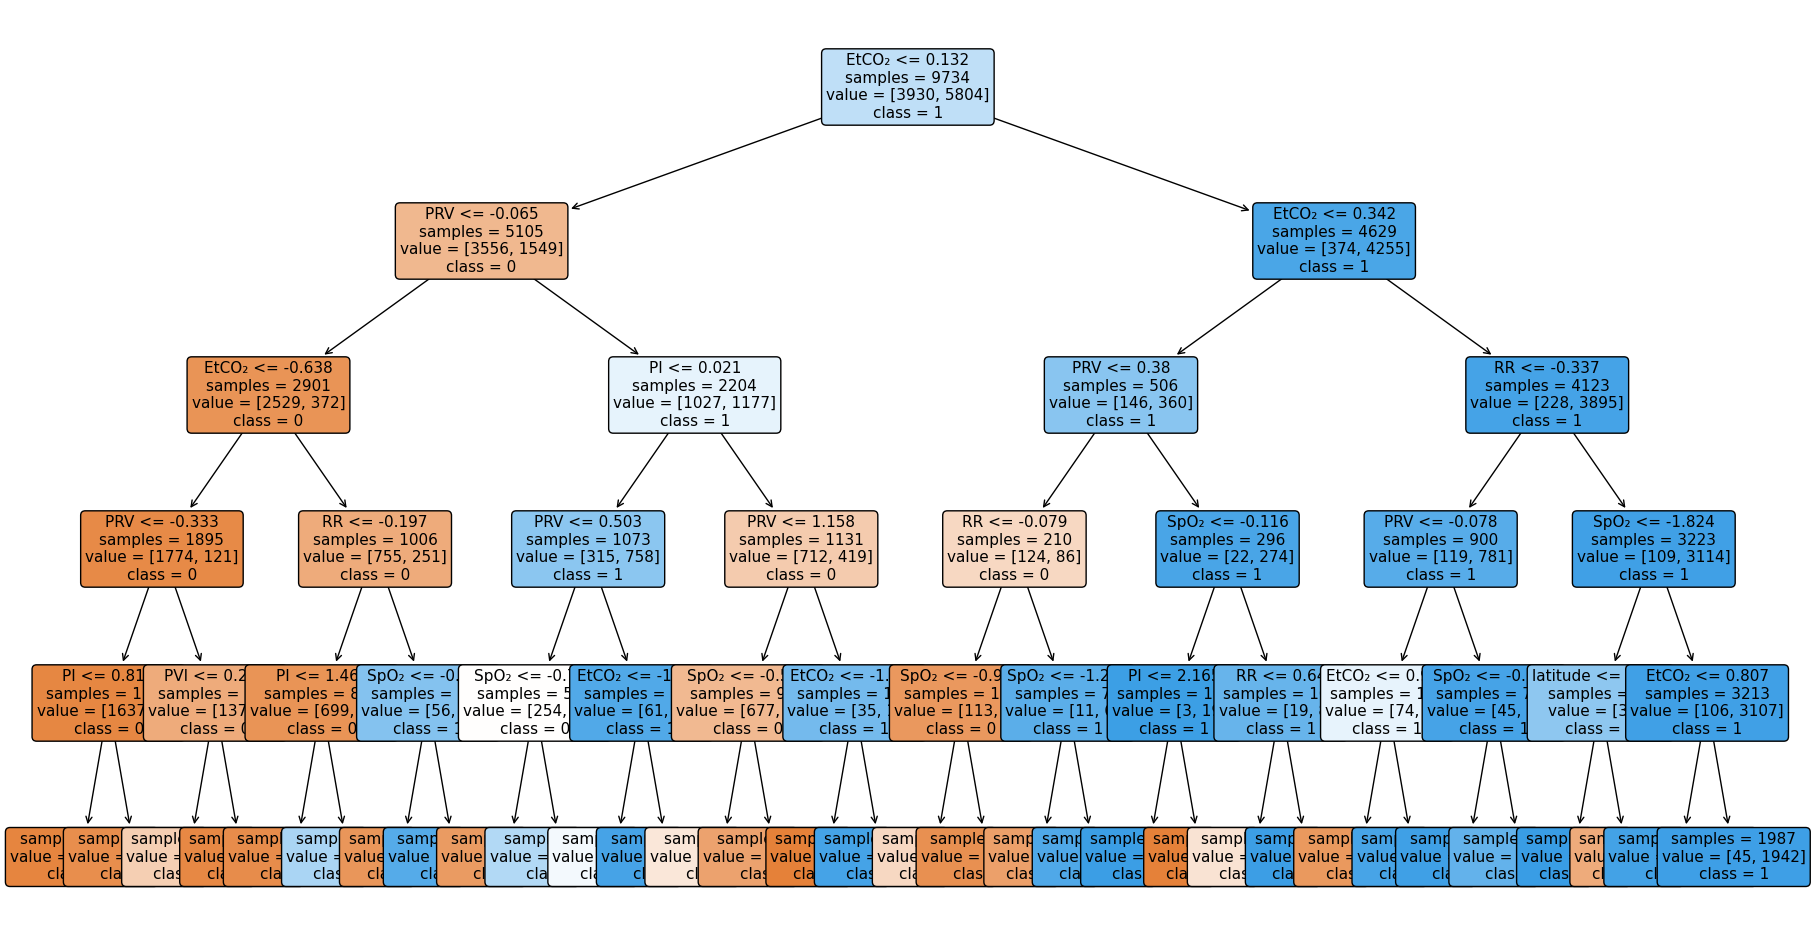

In [32]:
plt.figure(figsize=(22, 12))
plot_tree(
    dt_clf,
    feature_names=feature_cols,
    class_names=["0", "1"],
    filled=True,
    max_depth=5,
    impurity=False,
    proportion=False,
    rounded=True,
    fontsize=11
)
plt.show()


### 3.2-E Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

In [33]:
eval_results = []

def add_eval_result(name, y_true, y_pred):
    eval_results.append({
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    })

# Test metriky pre všetky tri modely
add_eval_result("ID3", y_test, y_test_pred_id3)
add_eval_result("DecisionTree", y_test, y_test_pred_dt)
add_eval_result("LogisticRegression", y_test, y_test_pred_lr)

eval_df = pd.DataFrame(eval_results)
eval_df


,model,accuracy,precision,recall
0,ID3,0.893591,0.916201,0.904204
1,DecisionTree,0.894002,0.923952,0.895934
2,LogisticRegression,0.857847,0.874576,0.889042
